# 05 — Model Training & Evaluation

**Goal:** Train machine learning models to predict `Global_active_power` (kW) based on our engineered features. We will establish a baseline, train a powerful XGBoost model, evaluate them, and save our performance visualizations to the `reports/figures/` folder.

## 1. Imports & Setup

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_palette('husl')
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

FEATURED_PATH = '../data/processed/featured.csv'
FIGURES_DIR = '../reports/figures/'
MODELS_DIR = '../models/'

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
print('Setup complete.')

Setup complete.


## 2. Load Data & Time-Based Split

**What:** Loading the engineered data and splitting it into Train (Past) and Test (Future).
**Why:** For Time Series, we **cannot** use random shuffling (like `train_test_split`). If we randomly shuffle, the model could use data from Wednesday to predict Tuesday. That's "data leakage" (cheating). We must train on the past and test on the future.

In [ ]:
# Load data, set datetime index
df = pd.read_csv(FEATURED_PATH, parse_dates=['datetime'], index_col='datetime')
    
# Target variable
TARGET = 'Global_active_power'

# Features: We use all columns EXCEPT the target itself and raw sub-meters (to avoid data leakage)
FEATURES = [
    'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'is_weekend', 
    'lag_1h', 'lag_24h', 'lag_48h', 
    'rolling_mean_6h', 'rolling_mean_24h',
    'unmetered_energy'
]

# Time-Based Split: Train on everything before 2010. Test on 2010.
split_idx = int(len(df) * 0.8)
train = df.iloc[:split_idx]
test = df.iloc[split_idx:]

X_train, y_train = train[FEATURES], train[TARGET]
X_test, y_test = test[FEATURES], test[TARGET]

print(f'Training size : {X_train.shape[0]} rows (Past)')
print(f'Testing size  : {X_test.shape[0]} rows (Future)')

Training size : 13514 rows (Past)
Testing size  : 3379 rows (Future)


## 3. Train the Models

**What:** Training a simple Linear Regression (as a baseline) and an XGBoost Regressor (Advanced Model).
**Why:** You should never jump straight to complex models. We train a basic linear model first. If XGBoost can't beat the linear model, then either our features are bad, or XGBoost is overkill.

In [11]:
print('Training Linear Regression (Baseline)...')
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

print('Training Ridge Regression...')
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

print('Training Random Forest...')
rf_model = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

print('Training XGBoost Regressor (Advanced)...')
# We use 100 trees (n_estimators). This takes a few seconds.
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_model.fit(X_train, y_train)
print('Training complete.')

Training Linear Regression (Baseline)...
Training Ridge Regression...
Training Random Forest...
Training XGBoost Regressor (Advanced)...
Training complete.


## 4. Evaluation Metrics

**What:** Predicting on the test set and calculating RMSE, MAE, and R².
**Why:** 
- **RMSE (Root Mean Squared Error):** Punishes large mistakes heavily. Measured in kW.
- **MAE (Mean Absolute Error):** The average mistake the model makes. Measured in kW.
- **R² (R-Squared):** Percentage of variance explained. 1.0 is perfect, 0.0 is guessing the average.

In [12]:
def evaluate(model, name):
    preds = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    print(f'--- {name} ---')
    print(f'RMSE : {rmse:.4f} kW')
    print(f'MAE  : {mae:.4f} kW')
    print(f'R²   : {r2:.4f}\n')
    return preds

lr_preds = evaluate(lr_model, 'Linear Regression (Baseline)')
ridge_preds = evaluate(ridge_model, 'Ridge Regression')
rf_preds = evaluate(rf_model, 'Random Forest Regressor')
xgb_preds = evaluate(xgb_model, 'XGBoost Regressor')

--- Linear Regression (Baseline) ---
RMSE : 0.4059 kW
MAE  : 0.2900 kW
R²   : 0.7498

--- Ridge Regression ---
RMSE : 0.4059 kW
MAE  : 0.2900 kW
R²   : 0.7498

--- Random Forest Regressor ---
RMSE : 0.3815 kW
MAE  : 0.2383 kW
R²   : 0.7790

--- XGBoost Regressor ---
RMSE : 0.3724 kW
MAE  : 0.2341 kW
R²   : 0.7894



## 5. Visualizing Predictions vs Actual (Time Series)

**What:** Plotting the model's predictions overlaid on top of the actual data for a 2-week slice.
**Why:** Numbers (like RMSE) don't tell the whole story. We need to see visually if the model captures the spikes (dinner time) and the troughs (overnight).

Saved visualization to ../reports/figures/actual_vs_predicted_ts.png


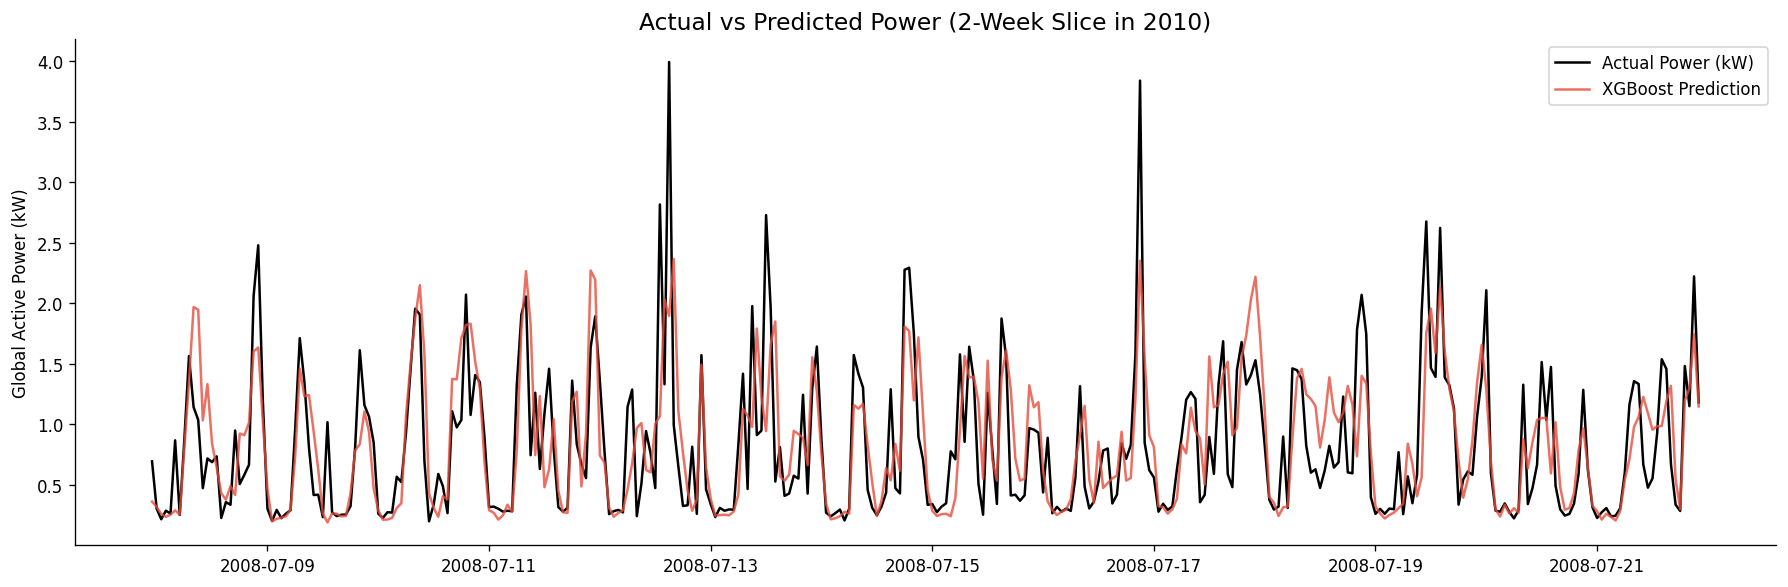

In [13]:
fig, ax = plt.subplots(figsize=(15, 5))

# Let's grab just 2 weeks of the test set so the chart is readable
start, end = 100, 436 # 336 hours = 14 days
plot_dates = y_test.index[start:end]

ax.plot(plot_dates, y_test.values[start:end], label='Actual Power (kW)', color='black', lw=1.5)
ax.plot(plot_dates, xgb_preds[start:end], label='XGBoost Prediction', color='#e74c3c', lw=1.5, alpha=0.8)

ax.set_title('Actual vs Predicted Power (2-Week Slice in 2010)', fontsize=14)
ax.set_ylabel('Global Active Power (kW)')
ax.legend()
plt.tight_layout()

# SAVE TO REPORTS DIRECTORY
plt.savefig(f'{FIGURES_DIR}actual_vs_predicted_ts.png', dpi=300)
print(f"Saved visualization to {FIGURES_DIR}actual_vs_predicted_ts.png")
plt.show()

## 6. Residual Analysis

**What:** Plotting a histogram and scatter plot of the Residuals (Actual value minus Predicted value).
**Why:** Residuals show us *where* the model fails. If the residuals form a perfect bell curve centered at 0, our model is healthy. If there's a skew, it means the model is consistently over-predicting or under-predicting.

Saved visualization to ../reports/figures/residual_analysis.png


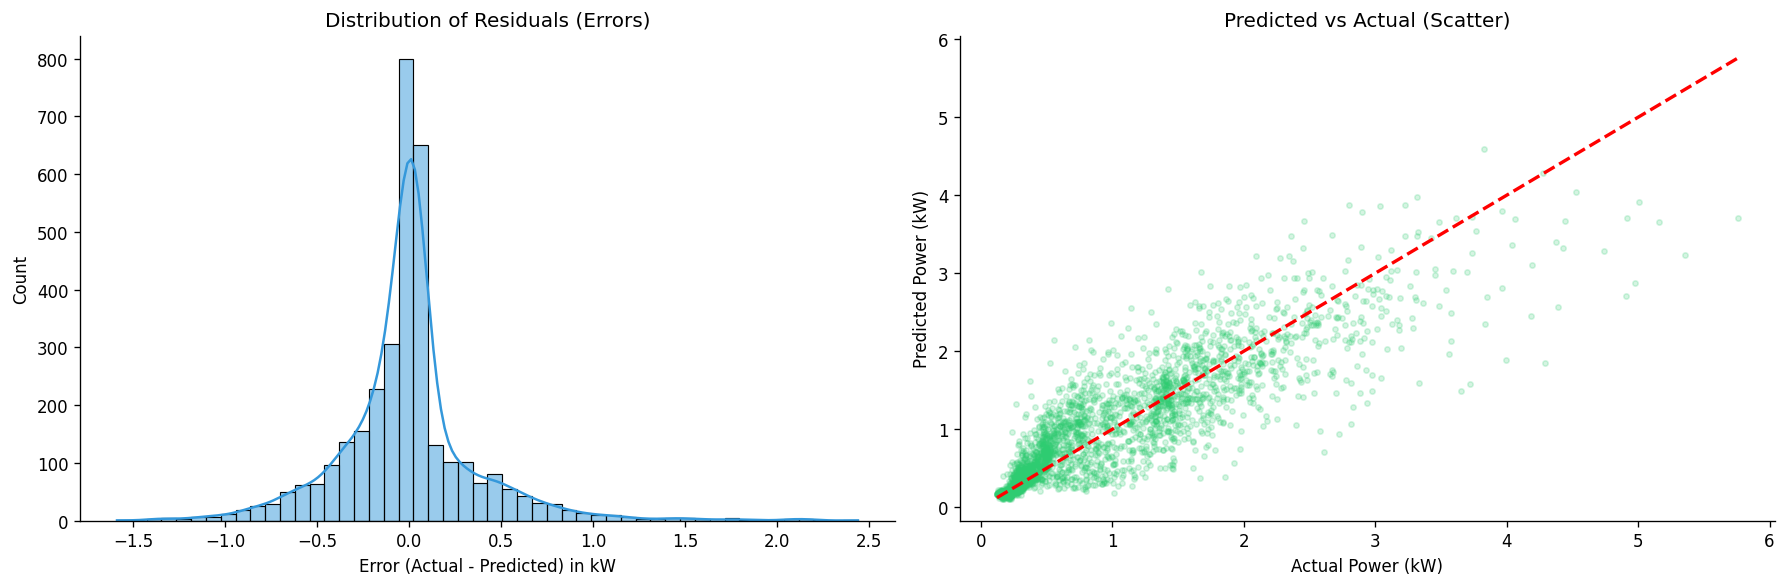

In [14]:
residuals = y_test - xgb_preds

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Histogram of errors
sns.histplot(residuals, bins=50, ax=ax1, color='#3498db', kde=True)
ax1.set_title('Distribution of Residuals (Errors)')
ax1.set_xlabel('Error (Actual - Predicted) in kW')

# Scatter plot: Predictions vs Actuals
ax2.scatter(y_test, xgb_preds, alpha=0.2, color='#2ecc71', s=10)
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Perfect prediction line
ax2.set_title('Predicted vs Actual (Scatter)')
ax2.set_xlabel('Actual Power (kW)')
ax2.set_ylabel('Predicted Power (kW)')

plt.tight_layout()

# SAVE TO REPORTS DIRECTORY
plt.savefig(f'{FIGURES_DIR}residual_analysis.png', dpi=300)
print(f"Saved visualization to {FIGURES_DIR}residual_analysis.png")
plt.show()

## 7. Feature Importance

**What:** Asking the XGBoost model which features it relied on the most to make its decisions.
**Why:** This makes the "black box" model interpretable. It validates our Feature Engineering work. If `unmetered_energy` or `lag_24h` is at the top, we know our engineered features were a massive success.

Saved visualization to ../reports/figures/feature_importance.png


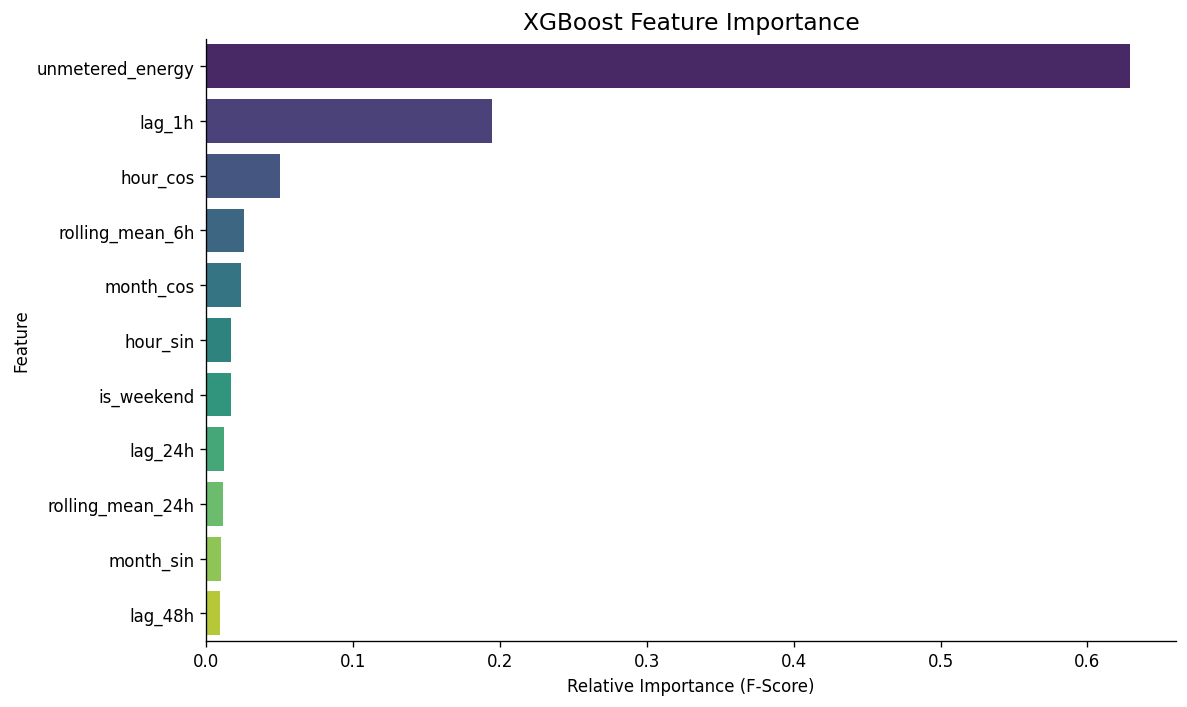

In [15]:
importance = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=importance, x='Importance', y='Feature', palette='viridis', ax=ax)
ax.set_title('XGBoost Feature Importance', fontsize=14)
ax.set_xlabel('Relative Importance (F-Score)')
plt.tight_layout()

# SAVE TO REPORTS DIRECTORY
plt.savefig(f'{FIGURES_DIR}feature_importance.png', dpi=300)
print(f"Saved visualization to {FIGURES_DIR}feature_importance.png")
plt.show()

## 8. Save the Best Model

**What:** Saving the trained XGBoost model to disk using `joblib`.
**Why:** So we don't have to retrain it every time we want to make a prediction in a future production app or web service.

In [16]:
# Save baseline
joblib.dump(lr_model, f'{MODELS_DIR}linear_baseline.pkl')
# Save advanced model
joblib.dump(xgb_model, f'{MODELS_DIR}xgboost_v1.pkl')

print(f"Saved models to {MODELS_DIR}")

Saved models to ../models/
